### **Description**

This recipe shows how to calculate Ocean Heat Transport (OHT) using annual-mean outputs from the National Oceanography Centre Near-Present-Day global eORCA1 configuration of NEMO forced using JRA55-do from 1976-2024.

For more details on this model configuration and the available outputs, users can explore the Near-Present-Day documentation [here](https://noc-msm.github.io/NOC_Near_Present_Day/).

---
### **Background**
Ocean Heat Transport (OHT) is a essential contribution to the Earth's energy balance, and can be defined as a function of latitude $\phi$ at time $t$ as follows:

$$OHT(\phi, t) = \rho_o c_p \int_{x_w}^{x_e} \int_{-H}^{\eta} v(\lambda, \phi, z, t)  \ \Theta (\lambda, \phi, z, t) \ dz \ dx$$

where the product of the meridional velocity $v(\lambda, \phi, z, t)$ and conservative temperature $\Theta (\lambda, \phi, z, t)$ is integrated both vertically from the sea surface $\eta$ to the seafloor $-H$ and zonally between the western $x_w$ and eastern $x_e$ boundaries of the basin. The reference density is $\rho_o$ and a constant ocean model heat capacity is $c_p^o$. 

---

In [1]:
# -- Import required packages -- #
import matplotlib.pyplot as plt
import xarray as xr

from nemo_cookbook import NEMODataTree

xr.set_options(display_style="text")

### **Using Dask**

**Optional: Connect Client to Dask Local Cluster to run analysis in parallel.**

Note that, although using Dask is not strictly necessary for this simple example using eORCA1, if we wanted to generalise this recipe to eORCA025 or eORCA12 outputs, using Dask would be essential to avoid unnecessary slow calculations using only a single process.

In [ ]:
# -- Initialise Dask Local Cluster -- #
import os

import dask
from dask.distributed import Client, LocalCluster

# Update temporary directory for Dask workers:
dask.config.set({'temporary_directory': f"{os.getcwd()}/dask_tmp",
                 'local_directory': f"{os.getcwd()}/dask_tmp"
                 })

# Create Local Cluster:
cluster = LocalCluster(n_workers=4, threads_per_worker=3, memory_limit='5GB')
client = Client(cluster)
client

### **Accessing NEMO Model Data**
**Let's begin by loading the grid variables for our eORCA1 NEMO model from the [JASMIN Object Store](https://help.jasmin.ac.uk/docs/short-term-project-storage/using-the-jasmin-object-store/)**. 

**Alternatively, you can replace the ``domain_filepath`` below with a file path to your domain_cfg.nc file and read this with xarray's ``open_dataset()`` function.**

In [3]:
# Define directory path to ancillary files:
domain_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/domain_cfg"

# Open eORCA1 NEMO model domain_cfg:
ds_domain = xr.open_zarr(domain_url, consolidated=True, chunks={})

ds_domain

<xarray.Dataset> Size: 709MB
Dimensions:       (y: 331, x: 360, nav_lev: 75)
Coordinates:
  * nav_lev       (nav_lev) int64 600B 0 1 2 3 4 5 6 7 ... 68 69 70 71 72 73 74
  * x             (x) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * y             (y) int64 3kB 0 1 2 3 4 5 6 7 ... 324 325 326 327 328 329 330
Data variables: (12/49)
    atlmsk        (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    bathy_metry   (y, x) float32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    bottom_level  (y, x) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1f           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1t           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1u           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    ...            ...
    top_level     (y, x) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    umask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    umaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    vmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    vmaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    wmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
Attributes:
    CfgName:    UNKNOWN
    CfgIndex:   -999
    Iperio:     1
    Jperio:     0
    NFold:      1
    NFtype:     F
    VertCoord:  zps
    IsfCav:     0
    file_name:  mesh_mask.nc
    TimeStamp:  01/03/2025 22:19:49 -0000

**Next, we need to import the conservative temperature stored at T-points in a single dataset.**

In [4]:
# Define directory path to model output files:
gridT_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/T1y"

# Construct NEMO model T-grid dataset, including conservative temperature (degC) and absolute salinity (g/kg):
ds_gridT = xr.open_zarr(gridT_url, consolidated=True, chunks={}).sel(time_counter=slice("1990-01", "2023-12"))

ds_gridT

<xarray.Dataset> Size: 28GB
Dimensions:                (time_counter: 34, y: 331, x: 360, deptht: 75,
                            axis_nbounds: 2)
Coordinates:
  * deptht                 (deptht) float32 300B 0.5058 1.556 ... 5.902e+03
    nav_lat                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lon                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    time_centered          (time_counter) datetime64[ns] 272B dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter           (time_counter) datetime64[ns] 272B 1990-07-02T12:0...
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/74)
    berg_latent_heat_flux  (time_counter, y, x) float32 16MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    deptht_bounds          (deptht, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
    e3t                    (time_counter, deptht, y, x) float32 1GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    empmr                  (time_counter, y, x) float32 16MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    evs                    (time_counter, y, x) float32 16MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ficeberg               (time_counter, y, x) float32 16MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ...                     ...
    ttrd_qns_li            (time_counter, y, x) float32 16MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    vohfcisf               (time_counter, deptht, y, x) float32 1GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vohflisf               (time_counter, deptht, y, x) float32 1GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vowflisf               (time_counter, deptht, y, x) float32 1GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    zos                    (time_counter, y, x) float32 16MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 16MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA1_1y_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2024-Dec-09 10:28:01 GMT
    uuid:         89824b34-5d44-4531-8344-fe1ce39fbb7b

**Next, we need to import the meridional velocity and vertical grid cell thicknesses stored at V-points in a single dataset.**

In [5]:
# Define directory path to model output files:
gridV_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/V1y"

# Construct NEMO model V-grid dataset, including vertical grid cell thicknesses (m) and meridional velocities (m/s):
ds_gridV = xr.open_zarr(gridV_url, consolidated=True, chunks={}).sel(time_counter=slice("1990-01", "2023-12"))

ds_gridV

<xarray.Dataset> Size: 6GB
Dimensions:               (depthv: 75, axis_nbounds: 2, time_counter: 34,
                           y: 331, x: 360)
Coordinates:
  * depthv                (depthv) float32 300B 0.5058 1.556 ... 5.902e+03
    nav_lat               (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lon               (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    time_centered         (time_counter) datetime64[ns] 272B dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter          (time_counter) datetime64[ns] 272B 1990-07-02T12:00...
Dimensions without coordinates: axis_nbounds, y, x
Data variables: (12/13)
    depthv_bounds         (depthv, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
    e3v                   (time_counter, depthv, y, x) float32 1GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    hfy                   (time_counter, y, x) float32 16MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    hfy_adv               (time_counter, y, x) float32 16MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    hfy_diff              (time_counter, y, x) float32 16MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    somesatr              (time_counter, y, x) float32 16MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ...                    ...
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 544B dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 544B dask.array<chunksize=(1, 2), meta=np.ndarray>
    v2o                   (time_counter, depthv, y, x) float32 1GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vmo                   (time_counter, depthv, y, x) float32 1GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vo                    (time_counter, depthv, y, x) float32 1GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vo_eiv                (time_counter, depthv, y, x) float32 1GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA1_1y_grid_V
    description:  ocean V grid variables
    title:        ocean V grid variables
    Conventions:  CF-1.6
    timeStamp:    2024-Dec-09 10:18:04 GMT
    uuid:         b77cb501-a564-4451-8908-d66fe201e54a

### **Creating a NEMODataTree**

**Next, let's create a NEMODataTree to store our domain and T- & V-grid variables for the eORCA1 model.**

In [6]:
# Define dictionary of grid datasets defining eORCA1 parent model domain with no child/grand-child nests:
# Note: domain_cfg z-dimension is expected to be named 'nav_lev'.
datasets = {"parent": {"domain": ds_domain, "gridT": ds_gridT, "gridV": ds_gridV}}

# Initialise a new NEMODataTree whose parent domain is zonally periodic & north-folding on F-points:
nemo = NEMODataTree.from_datasets(datasets=datasets, iperio=True, nftype="F", read_mask=True)

nemo

<xarray.DataTree 'NEMO model'>
Group: /
│   Dimensions:               (time_counter: 34, axis_nbounds: 2)
│   Coordinates:
│       time_centered         (time_counter) datetime64[ns] 272B dask.array<chunksize=(1,), meta=np.ndarray>
│     * time_counter          (time_counter) datetime64[ns] 272B 1990-07-02T12:00...
│   Dimensions without coordinates: axis_nbounds
│   Data variables:
│       time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 544B dask.array<chunksize=(1, 2), meta=np.ndarray>
│       time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 544B dask.array<chunksize=(1, 2), meta=np.ndarray>
│   Attributes:
│       nftype:   F
│       iperio:   True
├── Group: /gridT
│       Dimensions:                (time_counter: 34, j: 331, i: 360, k: 75,
│                                   axis_nbounds: 2)
│       Coordinates:
│         * deptht                 (k) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
│           time_centered          (time_counter) datetime64[ns] 272B dask.array<chunksize=(1,), meta=np.ndarray>
│           gphit                  (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           glamt                  (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│         * k                      (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
│         * j                      (j) int64 3kB 1 2 3 4 5 6 ... 326 327 328 329 330 331
│         * i                      (i) int64 3kB 1 2 3 4 5 6 ... 355 356 357 358 359 360
│       Dimensions without coordinates: axis_nbounds
│       Data variables: (12/80)
│           berg_latent_heat_flux  (time_counter, j, i) float32 16MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           deptht_bounds          (k, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
│           e3t                    (time_counter, k, j, i) float32 1GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
│           empmr                  (time_counter, j, i) float32 16MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           evs                    (time_counter, j, i) float32 16MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           ficeberg               (time_counter, j, i) float32 16MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           ...                     ...
│           e1t                    (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           e2t                    (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           top_level              (j, i) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           bottom_level           (j, i) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           tmask                  (k, j, i) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
│           tmaskutil              (j, i) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│       Attributes:
│           nftype:   F
│           iperio:   True
├── Group: /gridU
│       Dimensions:       (j: 331, i: 360, k: 75)
│       Coordinates:
│           gphiu         (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           glamu         (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│         * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 325 326 327 328 329 330 331
│         * i             (i) float64 3kB 1.5 2.5 3.5 4.5 ... 357.5 358.5 359.5 360.5
│       Data variables:
│           e1u           (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           e2u           (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           umask         (k, j, i) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
│           umaskutil     (j, i) int8

### **Calculating Ocean Heat Transport**
**Now we have constructed our `NEMODataTree`, let's calculate the global Ocean Heat Transport (OHT).**

**Note, we can also pass an ocean basin mask to `.integral()` to decompose the OHT by basin**

In [7]:
# Reference density [kg m-3]
rho0 = 1025
# Reference specific heat capacity [J kg-1 C-1]
cp0 = 3994

# Note, we need to interpolate conservative temperature from T-points to V-points to align with meridional velocity:
MHT = (rho0 * cp0 * nemo["gridT/thetao_con"].interp_to(to='V') * nemo["gridV/vo"]).integral(dims=["i", "k"])

MHT

<NEMODataTree 'NEMO model'>
  <NEMODataArray 'integral_ik(None)' (Domain: '.', Grid: 'gridV', Grid Type: 'V')>

<xarray.DataArray 'integral_ik(None)' (time_counter: 34, j: 331)> Size: 90kB
dask.array<sum-aggregate, shape=(34, 331), dtype=float64, chunksize=(1, 331), chunktype=numpy.ndarray>
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 272B 1990-07-02T12:00:00 ......
  * j              (j) float64 3kB 1.5 2.5 3.5 4.5 ... 328.5 329.5 330.5 331.5
    time_centered  (time_counter) datetime64[ns] 272B dask.array<chunksize=(1,), meta=np.ndarray>

**Notice that the resulting DataArray includes a dask array, so we haven't actually computed the diapycnal overturning yet. To do this, we need to call the ``.compute()`` method:**

In [8]:
MHT = MHT.compute()

### **Visualising the time-mean global Ocean Heat Transport (OHT)**

**Finally, let's visualise the results by plotting the time-mean global Ocean Heat Transport as a function of NEMO model j coordinate:**

Text(0, 0.5, 'Ocean Heat Transport (PW)')

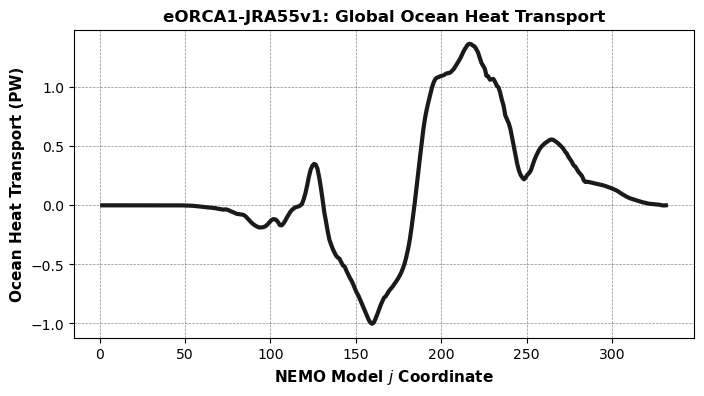

In [10]:
plt.figure(figsize=(8, 4))
plt.grid(visible=True, linestyle='--', linewidth=0.5, color='0.1', alpha=0.5)

# Plot time-mean meridional heat transport for the Atlantic Ocean in Petawatts (1 PW = 10^15 W):
(1E-15 * MHT.mean(dim="time_counter")).plot(linewidth=3, color='0.1')

# Axes labels:
plt.title('eORCA1-JRA55v1: Global Ocean Heat Transport', fontdict={'size':12, 'weight':'bold'})
plt.xlabel('NEMO Model $j$ Coordinate', fontdict={'size':11, 'weight':'bold'})
plt.ylabel('Ocean Heat Transport (PW)', fontdict={'size':11, 'weight':'bold'})